# Using Logistic Regression to Classify Raisin Varieties

In this notebook, we use logistic regression to perform binary classification of raisin varieties. The [Raisin dataset](https://archive.ics.uci.edu/dataset/850/raisin) comes from UC Irvine's Machine Learning Repository.

The two raisin classes we are trying to classify are the Kecimen and Besni raisins, which are types of raisins grown in Turkey.Researchers photographed 900 raisin grains (450 per variety) using a computer vision system and extracted 7 morphological features per grain.

This notebook aims to classify which raisin variety a grain belongs to given the seven shape measurements.  

| **Feature** | **Type** | **Description** |
|---|---|---|
| Area | Integer | Number of pixels within the grain boundary |
| MajorAxisLength | Continuous | Length of the main axis, which is the longest line that can be drawn on the raisin |
| MinorAxisLength | Continuous | Length of the small axis, which is the shortest line that can be drawn on the raisin |
| Eccentricity | Continuous | Eccentricity of the equivalent ellipse |
| ConvexArea | Integer |  Number of pixels of the smallest convex shell of the region formed by the raisin |
| Extent | Continuous | Ratio of grain pixels to bounding-box pixels |
| Perimeter | Continuous | Perimeter of the grain boundary |

**Target:** Kecimen (0) or Besni (1)

---

## Load and Explore Data

In [23]:
# Import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ml_package import (
    LogisticRegression,
    PCA,
    StandardScaler,
    train_test_split,
    classification_metrics,
)

np.random.seed(42)

In [10]:
# Load data and assign features and target
df = pd.read_csv("Raisin_Dataset.csv")

X = df.drop(columns = ["Class"])
y = df["Class"]

df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
0,87524,442.246011,253.291155,0.819738,90546,0.758651,1184.040,Kecimen
1,75166,406.690687,243.032436,0.801805,78789,0.684130,1121.786,Kecimen
2,90856,442.267048,266.328318,0.798354,93717,0.637613,1208.575,Kecimen
3,45928,286.540559,208.760042,0.684989,47336,0.699599,844.162,Kecimen
4,79408,352.190770,290.827533,0.564011,81463,0.792772,1073.251,Kecimen


In [12]:
#Descriptive statistics 
X.describe().round(3)

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter
count,900.000,900.000,900.000,900.000,900.00,900.000,900.000
mean,87804.128,430.930,254.488,0.782,91186.09,0.700,1165.907
std,39002.111,116.035,49.989,0.090,40769.29,0.053,273.764
min,25387.000,225.630,143.711,0.349,26139.00,0.380,619.074
25%,59348.000,345.443,219.111,0.742,61513.25,0.671,966.411
50%,78902.000,407.804,247.848,0.799,81651.00,0.707,1119.509
75%,105028.250,494.187,279.889,0.843,108375.75,0.735,1308.390
max,235047.000,997.292,492.275,0.962,278217.00,0.835,2697.753


---

Below, we plot both of the raisin classes' distributions across each feature. These graphs show that Besni raisins are systematically larger (higher Area, Perimeter, MajorAxisLength) than Kecimen, while the Eccentricity distributions overlap more, suggesting that shape alone is less discriminative than size. This suggests that a linear classifier will perform well overall but may struggle on the eccentricity dimension.

---

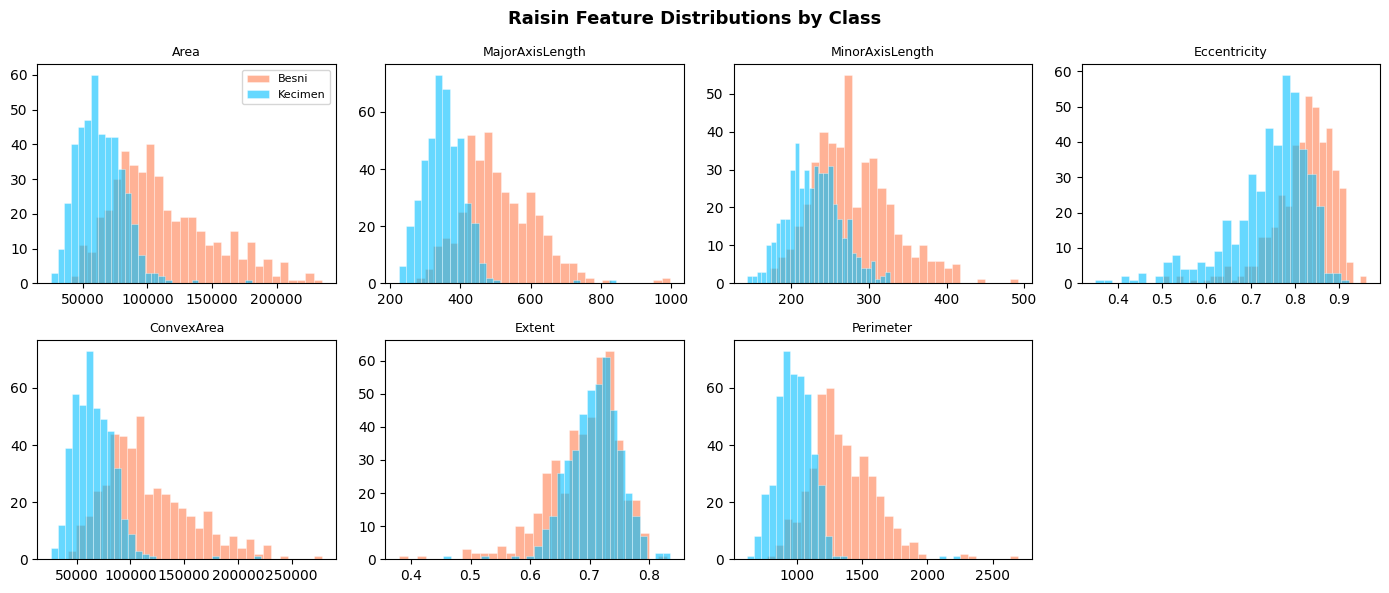

In [15]:
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
fig.suptitle("Raisin Feature Distributions by Class", fontsize=13, fontweight="bold")

palette = {"Kecimen": "deepskyblue", "Besni": "coral"}
for ax, col in zip(axes.flat, X.columns):
    for cls in np.unique(y):
        ax.hist(X[col][y == cls], bins=30, alpha=0.6,
                label=cls, color=palette[cls], edgecolor="white", linewidth=0.4)
    ax.set_title(col, fontsize=9)

# Hide the last (unused) subplot
axes.flat[-1].set_visible(False)
axes.flat[0].legend(fontsize=8)
plt.tight_layout()
plt.show()


## Data Preprocessing

Before we proceed with training the model, we need to use map each class to an integer label. We label "Kecimen" class observations as 0 and "Besni" as 1. We use a stratified split to maintain the 50/50 balance in both train and test sets. We also standardize the data, which is important for logistic regression because it ensures all features have comparable gradient magnitudes.

---

In [16]:
# Encode labels
label_map = {"Kecimen": 0, "Besni": 1}
y = np.array([label_map[c] for c in y])

X_arr = X.values.astype(float)
X_train, X_test, y_train, y_test = train_test_split(X_arr, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}")
print(f"Train class balance: {np.bincount(y_train)}")

Train: 720  |  Test: 180
Train class balance: [360 360]


## Train the Logistic Regression Model

Now, we can train the model. Here, we use a learning rate of 0.1. This is higher than the linear regression case because the sigmoid-compressed gradients are smaller in magnitude and benefit from a larger step. 

---

In [18]:
# Define and fit the model
model = LogisticRegression()
model.train(X_train_s, y_train, eta=0.1, epochs=1000, task="binary")
print(f"Final loss: {model.losses[-1]:.4f}")


Final loss: 0.3673


---

The graph below plots the binary cross-entropy loss against the epoch number. The curve shows a steep descent in the first few hundred epochs followed by a flattening plateau, indicating convergence.

---


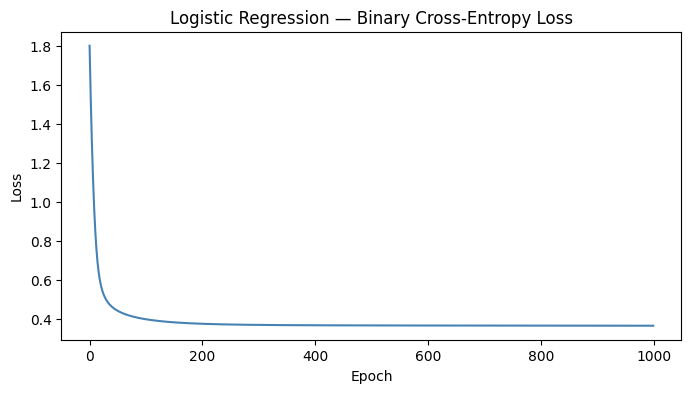

In [20]:
plt.figure(figsize=(8, 4))
plt.plot(model.losses, color = "steelblue", linewidth=1.5)
plt.title("Logistic Regression — Binary Cross-Entropy Loss", fontsize=12)
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.show()


## Evaluation

Now that we have trained our model, it's time to evaluate it's performance on the test set. Here, we use the full suite of evaluation methods included in the `LogisticRegression` class.

---

In [21]:
# Evaluation metrics
print(f"  Accuracy  : {model.accuracy(X_test_s, y_test):.4f}")
print(f"  Precision : {model.precision(X_test_s, y_test, average='binary'):.4f}")
print(f"  Recall    : {model.recall(X_test_s, y_test, average='binary'):.4f}")
print(f"  F1 Score  : {model.f1_score(X_test_s, y_test, average='binary'):.4f}")

  Accuracy  : 0.8778
  Precision : 0.8864
  Recall    : 0.8667
  F1 Score  : 0.8764


---

Across the four different evaluation metrics, our logistic regression model predicted the correct raisin variety about 88% of the time on the test set. This highlights how powerful logistic regression can be for binary classification tasks with linearly separable data.

Below, we compute the confusion matrix, with the off-diagonal cells representing misclassifications. 

---

Confusion Matrix (rows=actual, cols=predicted):
              Pred Kecimen  Pred Besni
True Kecimen       80            10
True Besni         12            78


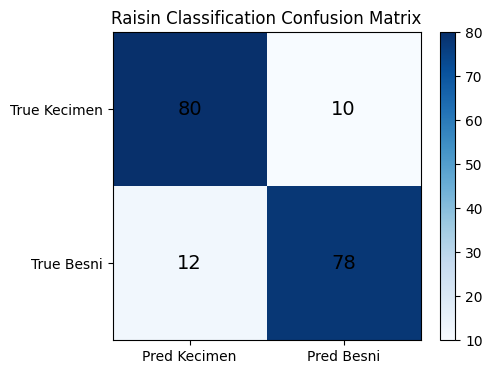

In [22]:
cm = model.confusion_matrix(X_test_s, y_test)
print("Confusion Matrix (rows=actual, cols=predicted):")
print(f"              Pred Kecimen  Pred Besni")
print(f"True Kecimen     {cm[0,0]:4d}          {cm[0,1]:4d}")
print(f"True Besni       {cm[1,0]:4d}          {cm[1,1]:4d}")

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["Pred Kecimen", "Pred Besni"])
ax.set_yticklabels(["True Kecimen", "True Besni"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=14, color="black")
plt.colorbar(im, ax=ax)
ax.set_title("Raisin Classification Confusion Matrix")
plt.show()


## Visualize the Decision Boundary

Because our data contains seven features, we use PCA to reduce our dataset to two dimensions so that we can plot the decision boundary.

---

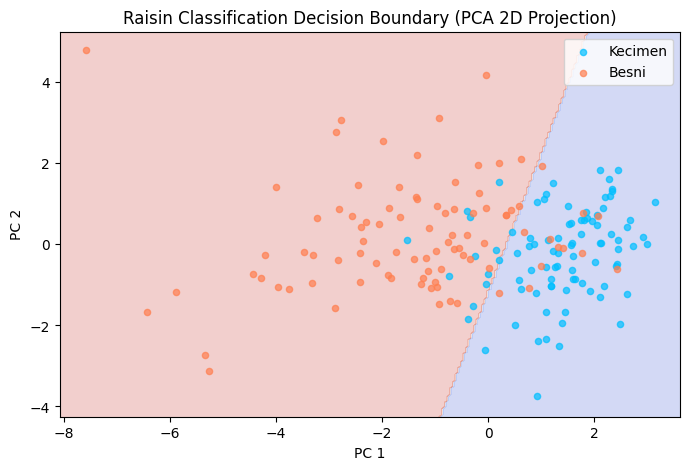

In [26]:
pca = PCA(n_components=2)
X_test_2d = pca.fit_transform(X_test_s)

# Fit a fresh logistic regression in 2D for the plot
model2d = LogisticRegression()
X_train_2d = pca.transform(X_train_s)
model2d.train(X_train_2d, y_train, eta=0.1, epochs=1000, task="binary")

# Mesh
h = 0.05
x_min, x_max = X_test_2d[:, 0].min() - 0.5, X_test_2d[:, 0].max() + 0.5
y_min, y_max = X_test_2d[:, 1].min() - 0.5, X_test_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = model2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8, 5))
ax.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
for cls, label, color in [(0, "Kecimen", "deepskyblue"), (1, "Besni", "coral")]:
    mask = y_test == cls
    ax.scatter(X_test_2d[mask, 0], X_test_2d[mask, 1],
               label=label, s=20, alpha=0.7, color=color)
ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2")
ax.set_title("Raisin Classification Decision Boundary (PCA 2D Projection)", fontsize=12)
ax.legend()
plt.show()

---

Overall, the model's 88% accuracy shows that a linear classifier in the standardised feature space is a very strong fit for this problem. The decision boundary plot confirms that the two raisin classes are largely (but not perfectly) linearly separable in PCA space.

---